# **IBEX35 Portfolio Optimisation**

### **Efficient Frontier**

In [53]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco
import os, sys
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from src.data import daily_returns, num_assets, mean_daily_returns, covar_daily_returns, tickers
from config import random_seed, num_random_portfolios, trading_days, risk_free_rate

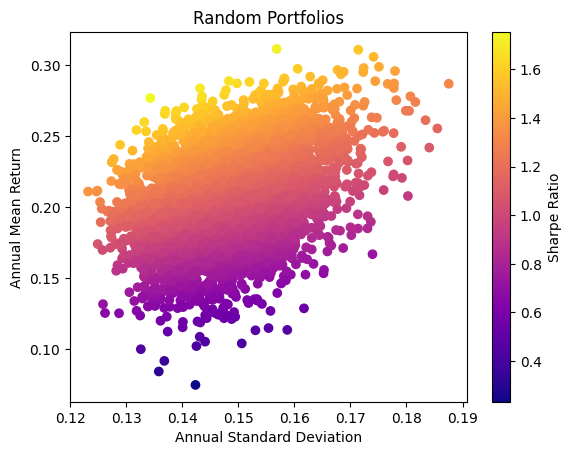

In [54]:
# Generate 5000 random portfolios (no short positions)
rng = np.random.default_rng(random_seed)
random_weights = rng.dirichlet(alpha=np.ones(num_assets),size=num_random_portfolios)

# Calculate the random portfolio statistics
random_daily_returns = daily_returns @ random_weights.T
random_mean_daily = random_daily_returns.mean()
random_mean_annual = random_mean_daily * trading_days
random_std_daily = random_daily_returns.std()
random_std_annual = random_std_daily * np.sqrt(trading_days)
random_sharpe_ratios = (random_mean_annual - risk_free_rate) / random_std_annual

# Plot the random portfolios
plt.scatter(random_std_annual, random_mean_annual, c=random_sharpe_ratios, cmap='plasma')
plt.xlabel('Annual Standard Deviation')
plt.ylabel('Annual Mean Return')
plt.title('Random Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.show()

In this case, we have generated 5000 portfolios with random weights (no shorts, no leverage) allocated to the 35 equities in the IBEX 35 stock index as of 01/10/2026. 

The efficient frontier represents the portfolios with the highest expected returns for a particular volatility, or vice versa. That is, the portfolios with the best risk-reward ratio or Sharpe ratio (the lightest yellow ones in this case).

### **Markowitz Optimisation**

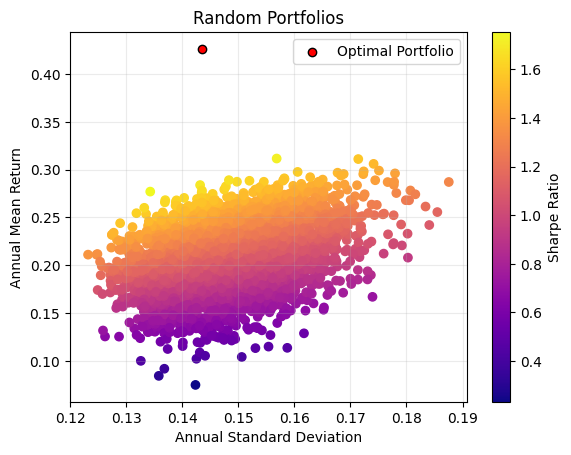

In [55]:
# Negative Sharpe Function
def negative_sharpe_optimisation(weights):
    numerator = (mean_daily_returns @ weights) - (risk_free_rate/trading_days)
    denominator = np.sqrt(weights @ covar_daily_returns @ weights)
    return -numerator / denominator

# Constraints
cons = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
weights_0 = np.ones(num_assets) / num_assets
args = ()
bounds = [(0, 1)] * num_assets # No short positions, no leverage

# Result of the optimisation
result = sco.minimize(negative_sharpe_optimisation, weights_0, method='SLSQP', bounds=bounds, constraints=cons, args=args)
weights_no_shorts = pd.Series(result.x).to_numpy()

## Calculate metrics for the optimal portfolio
optimal_daily_returns = daily_returns @ weights_no_shorts.T
optimal_mean_daily = optimal_daily_returns.mean()
optimal_mean_annual = optimal_mean_daily * trading_days
optimal_std_daily = optimal_daily_returns.std()
optimal_std_annual = optimal_std_daily * np.sqrt(trading_days)
optimal_sharpe = ((optimal_mean_annual - risk_free_rate) / optimal_std_annual)


# Plot graphs

## 5,000 random portfolios
random_scatter = plt.scatter(random_std_annual, random_mean_annual, c=random_sharpe_ratios, cmap='plasma')

## Maximum-Sharpe portfolio: no short positions
plt.scatter(optimal_std_annual, optimal_mean_annual, color="red", marker="o",edgecolors="black", linewidths=1, label="Optimal Portfolio")

plt.colorbar(random_scatter, label='Sharpe Ratio')
plt.xlabel("Annual Standard Deviation")
plt.ylabel("Annual Mean Return")
plt.title("Random Portfolios")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

After running the optimisation and finding the portfolio with the highest Sharpe ratio subject to no short positions and no leverage, we get the red dot. As we can see, in this case we get a much higher annual expected return for a much lower volatility than the portfolios in the efficient frontier offer. 

However, this is one of the issues of using this historical data: Markowitz optimisation often gives us unrealistic corner solutions that would not have been feasible to achieve in actual market conditions.

To solve this, we will calculate another optimal portfolio with a different constraint: maximum weight per asset of 5%.

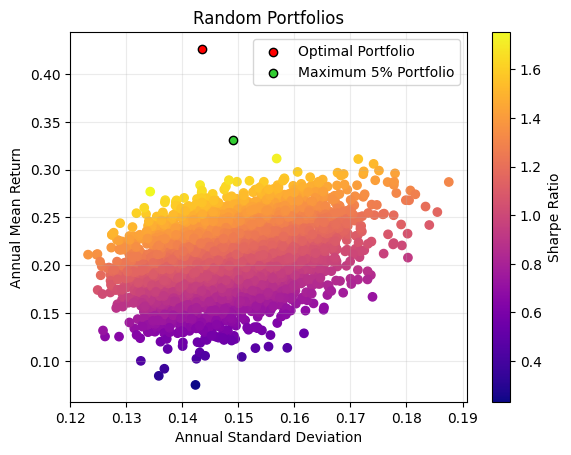

In [56]:
# Bounds for the optimisation (maximum 5% allocation per asset & no short positions)
bounds = [(0, 0.05)] * num_assets 

# Result of the optimisation
result = sco.minimize(negative_sharpe_optimisation, weights_0, method='SLSQP', bounds=bounds, constraints=cons, args=args)
weights_max_5_pp = pd.Series(result.x).to_numpy()

# Calculate metrics for the no short positions portfolio
max_5_pp_daily_returns = daily_returns @ weights_max_5_pp.T
max_5_pp_mean_daily = max_5_pp_daily_returns.mean()
max_5_pp_mean_annual = max_5_pp_mean_daily * trading_days
max_5_pp_std_daily = max_5_pp_daily_returns.std()
max_5_pp_std_annual = max_5_pp_std_daily * np.sqrt(trading_days)
max_5_pp_sharpe = ((max_5_pp_mean_annual - risk_free_rate) / max_5_pp_std_annual)

# Plot graphs
random_scatter = plt.scatter(random_std_annual, random_mean_annual, c=random_sharpe_ratios, cmap='plasma')
plt.scatter(optimal_std_annual, optimal_mean_annual, color="red", marker="o",edgecolors="black", linewidths=1, label="Optimal Portfolio")
plt.scatter(max_5_pp_std_annual, max_5_pp_mean_annual, color="limegreen", marker="o", edgecolors="black", linewidths=1, label="Maximum 5% Portfolio")
plt.colorbar(random_scatter, label='Sharpe Ratio')
plt.xlabel("Annual Standard Deviation")
plt.ylabel("Annual Mean Return")
plt.title("Random Portfolios")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

As we can see, it is a more realistic portfolio which seems to lie more in line with the rest of the efficient frontier.

We will also compare it with an equal weights portfolio.

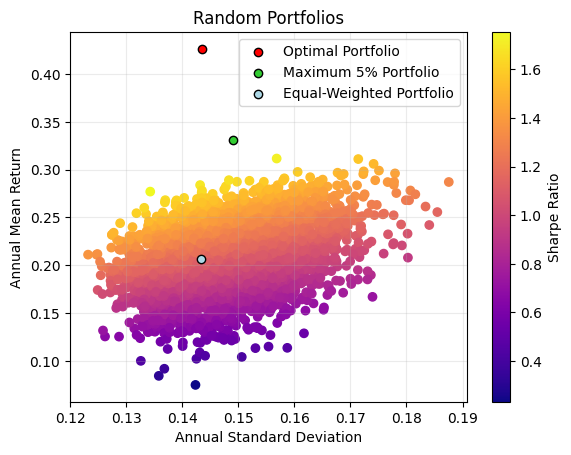

In [57]:
# Weights for the equal-weighted portfolio
weights_equal = np.ones(num_assets) / num_assets

# Calculate metrics for the equal-weighted portfolio
equal_daily_returns = daily_returns @ weights_equal.T
equal_mean_daily = equal_daily_returns.mean()
equal_mean_annual = equal_mean_daily * trading_days
equal_std_daily = equal_daily_returns.std()
equal_std_annual = equal_std_daily * np.sqrt(trading_days)
equal_sharpe = ((equal_mean_annual - risk_free_rate) / equal_std_annual)

# Plot graphs
random_scatter = plt.scatter(random_std_annual, random_mean_annual, c=random_sharpe_ratios, cmap='plasma')
plt.scatter(optimal_std_annual, optimal_mean_annual, color="red", marker="o",edgecolors="black", linewidths=1, label="Optimal Portfolio")
plt.scatter(max_5_pp_std_annual, max_5_pp_mean_annual, color="limegreen", marker="o", edgecolors="black", linewidths=1, label="Maximum 5% Portfolio")
plt.scatter(equal_std_annual, equal_mean_annual, color="lightblue", marker="o", edgecolors="black", linewidths=1, label="Equal-Weighted Portfolio")
plt.colorbar(random_scatter, label='Sharpe Ratio')
plt.xlabel("Annual Standard Deviation")
plt.ylabel("Annual Mean Return")
plt.title("Random Portfolios")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

As we can see, an equal-weighted portfolio would have produced average returns compared with the cloud of 5000 random-weighted portfolios.

*For the rest of the analysis, we will use the optimal portfolio subject to a maximum weight of 5% per equity as our market portfolio.*

### **Tobin - Capital Markets Line**

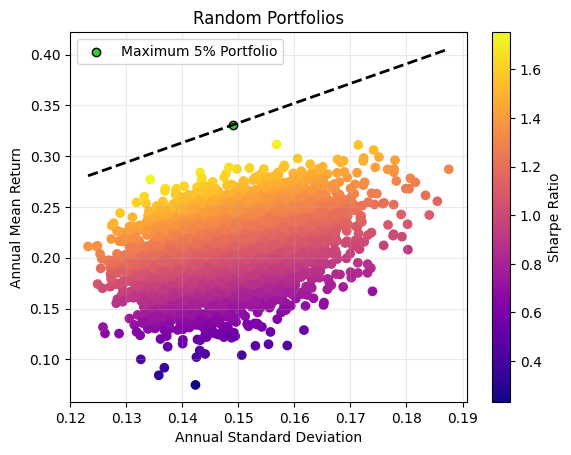

In [58]:
# We generate the Capital Market Line
cml_std = np.linspace(random_std_annual.min(),random_std_annual.max())
cml_return = (risk_free_rate + max_5_pp_sharpe * cml_std)

# Plot the graphs
random_scatter = plt.scatter(random_std_annual, random_mean_annual, c=random_sharpe_ratios, cmap='plasma')
plt.scatter(max_5_pp_std_annual, max_5_pp_mean_annual, color="limegreen", marker="o", edgecolors="black", linewidths=1, label="Maximum 5% Portfolio")
plt.colorbar(random_scatter, label='Sharpe Ratio')
plt.xlabel("Annual Standard Deviation")
plt.ylabel("Annual Mean Return")
plt.title("Random Portfolios")
plt.legend()
plt.grid(alpha=0.25)
plt.plot(
    cml_std,
    cml_return,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Capital Market Line"
)
plt.show()

When we include the risk-free asset, we can combine it with our optimal portfolio to obtain a set of optimal portfolios known as the capital markets line. 

We can combine the risk-free asset and our optimal portfolio in the quantities we choose to obtain a certain return for the lowest possible volatility or vice versa. 

In the projected model, we do permit shorting the risk-free asset. That is, getting indebted at the risk-free rate to increase equity or market exposure to maximise the possible returns. 

### **Conclusion & Limitations**

In [ ]:
# Optimal Portfolio Weights (Maximum 5% Allocation, No Short Positions)
weights_max_5_pp = pd.Series(weights_max_5_pp, index=tickers)
print(weights_max_5_pp.round(4))

ACS.MC     0.0500
ACX.MC     0.0209
BBVA.MC    0.0500
BKT.MC     0.0000
ANA.MC     0.0331
CABK.MC    0.0000
ENG.MC     0.0500
NTGY.MC    0.0500
GRF.MC     0.0500
FER.MC     0.0000
RED.MC     0.0000
ITX.MC     0.0500
REP.MC     0.0500
IBE.MC     0.0000
IDR.MC     0.0000
MAP.MC     0.0000
TEF.MC     0.0500
SCYR.MC    0.0500
SAB.MC     0.0500
SAN.MC     0.0000
COL.MC     0.0500
IAG.MC     0.0500
ELE.MC     0.0000
AMS.MC     0.0447
ROVI.MC    0.0500
SLR.MC     0.0000
FDR.MC     0.0500
MTS.MC     0.0500
MRL.MC     0.0000
LOG.MC     0.0500
AENA.MC    0.0500
CLNX.MC    0.0000
UNI.MC     0.0013
ANE.MC     0.0000
PUIG.MC    0.0500
dtype: float64


In [63]:
print(f"Market Portfolio Mean Annual Return: {max_5_pp_mean_annual*100:.2f}%")
print(f"Market Portfolio Standard Deviation Annual: {max_5_pp_std_annual*100:.2f}%")
print(f"Market Portfolio Sharpe Ratio: {max_5_pp_sharpe:.4f}")

Market Portfolio Mean Annual Return: 33.09%
Market Portfolio Standard Deviation Annual: 14.91%
Market Portfolio Sharpe Ratio: 1.9406


As we can see, the optimal portfolio we established would earn a mean annual return of 33.09%, with an annual standard deviation of 14.91% and a Sharpe ratio of 1.94.

We have already briefly mentioned some of the limitations of these models, such as it usually finding unrealistic corner solutions as the optimal portfolio. To fix this, you can set various assumptions such as no short positions and a maximum weight allocation per asset. 

Another severe limitation is the fact that we are using past returns to model future returns. In reality, historical returns are not indicative of future performance of a financial asset and should not be used in this manner. This method can point out what would have been the best theoretical portfolio in a previous period of time, but it has no predictive credibility.

Finally, as I previously mentioned, the CML allows the lending and borrowing of money at the risk-free rate. However, in reality, frictionless borrowing such as this does not exist. There are also several other market distortions, such as taxes, which impact the returns and behaviour of market participants.

In conclusion, these models are very useful for modeling historical market tendencies and learning how you can optimise portfolios using long and short positions, as well as debt to leverage a certain position.

These models could have real predictive power and credibility if instead of using historical returns we could have a better description of future asset returns. 

The only method I can think of would be to establish an intrinsic value metric for a series of assets (DCF). Under the assumption that under a certain period of time the market would revalue these assets to their intrinsic value, we can obtain some metric of expected returns. We could then use these expected returns to calcuate the optimal portfolio. However, the technical feasibility seems somewhat farfetched, considering that a single DCF analysis requires hours of work and can still be biased or miss a certain valuation factor, wich would throw off the entire model.